In [1]:
#CLASSIFICATION

#Part A

#Only these 5:

#Logistic Regression
#KNN
#Gaussian Naive Bayes
#Decision Tree
#SVC

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.tree import DecisionTreeClassifier

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [3]:
df = pd.read_csv("classification.csv")

df.head()

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15,8,7,1,0,1


In [4]:
print(df.columns.tolist())
print("Shape:", df.shape)

['id', 'battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi']
Shape: (1000, 21)


In [5]:
print(df["battery_power"].value_counts())

battery_power
1981    5
1074    5
900     4
529     4
1715    4
       ..
635     1
1797    1
1895    1
609     1
1185    1
Name: count, Length: 721, dtype: int64


In [6]:
#Dataset Audit
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

print("\nClass Distribution:")
print(df["battery_power"].value_counts())

Shape: (1000, 21)

Data Types:
id                 int64
battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
dtype: object

Missing Values:
id               0
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
dtype: int64



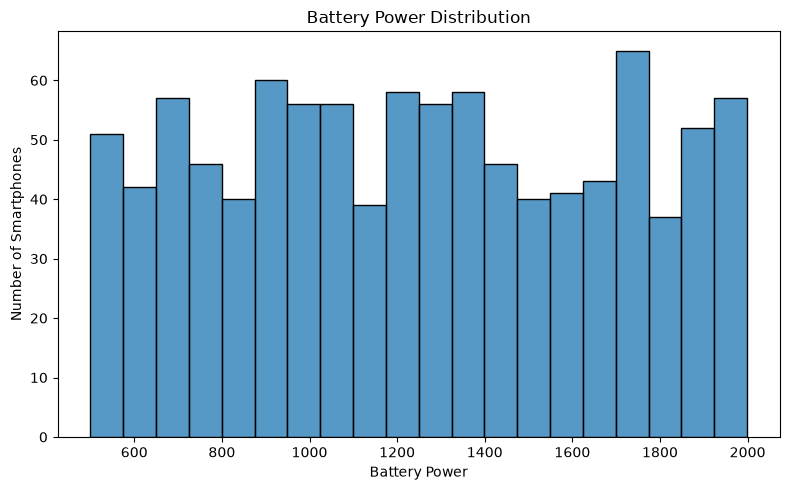

In [7]:
#Class Distribution
# Battery Power Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="battery_power",
    bins=20
)

plt.title("Battery Power Distribution")
plt.xlabel("Battery Power")
plt.ylabel("Number of Smartphones")

plt.tight_layout()
plt.show()

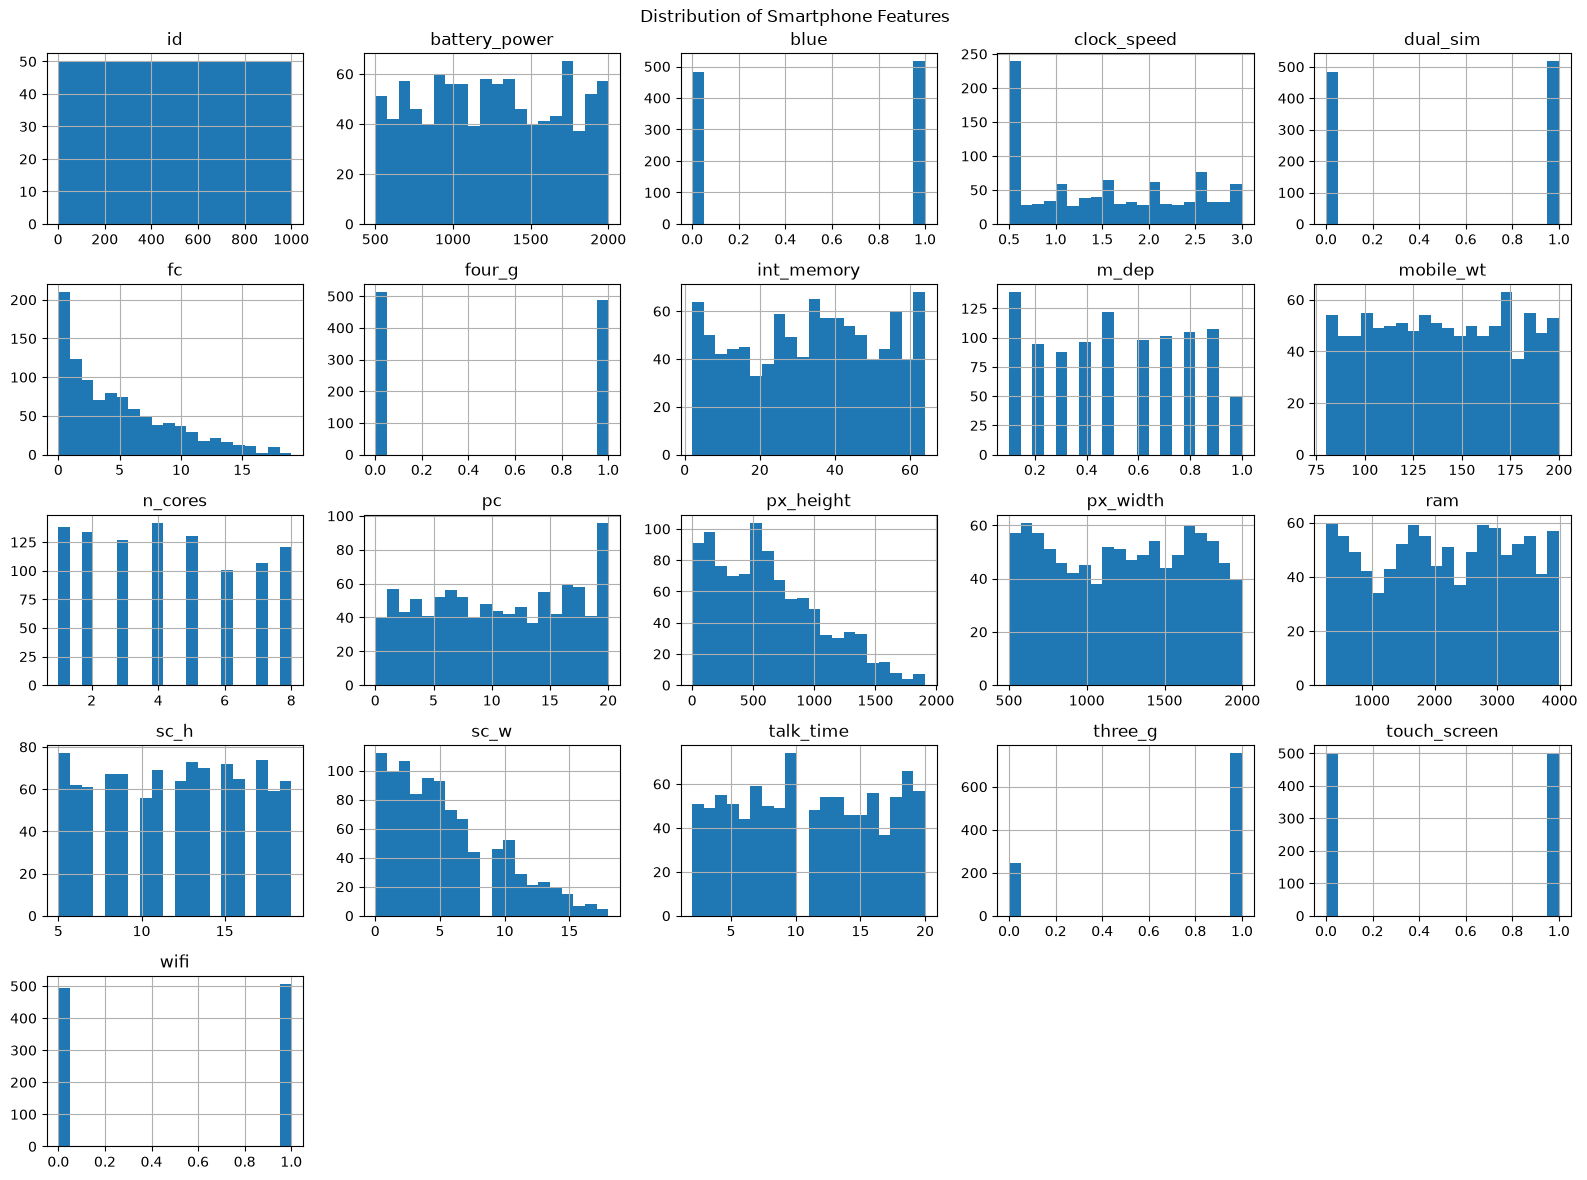

In [8]:
#Feature Distributions
numeric_features = df.select_dtypes(
    include=np.number
).columns

df[numeric_features].hist(
    figsize=(16, 12),
    bins=20
)

plt.suptitle(
    "Distribution of Smartphone Features"
)

plt.tight_layout()
plt.show()

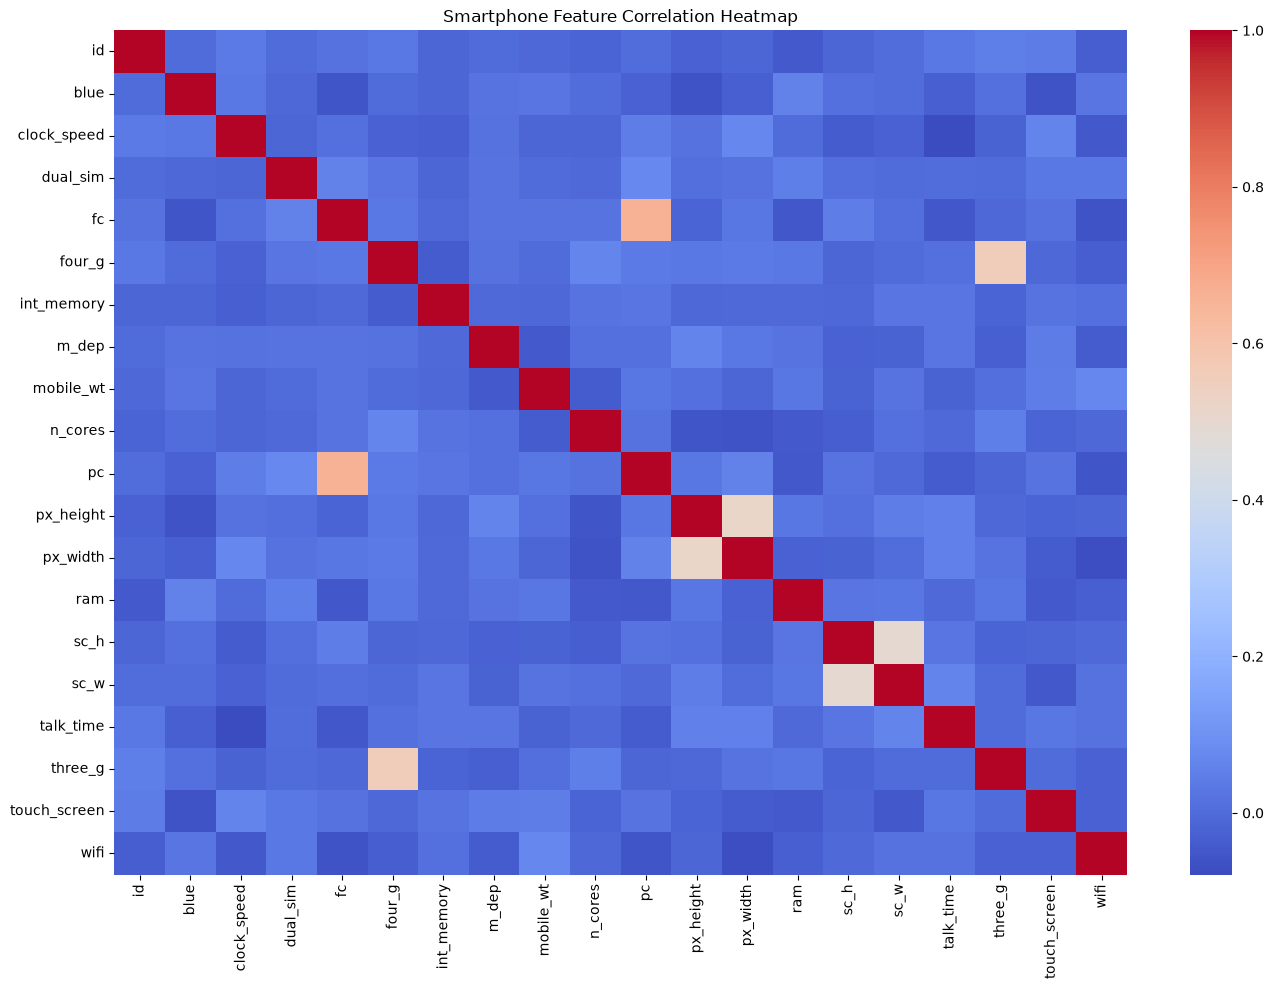

In [9]:
#Correlation
plt.figure(figsize=(14, 10))

sns.heatmap(
    df.drop(columns=["battery_power"]).corr(),
    cmap="coolwarm"
)

plt.title(
    "Smartphone Feature Correlation Heatmap"
)

plt.tight_layout()
plt.show()

In [10]:
#Feature Engineering
df["screen_area"] = (
    df["sc_h"] *
    df["sc_w"]
)

df["pixel_count"] = (
    df["px_height"] *
    df["px_width"]
)

df["battery_per_weight"] = (
    df["battery_power"] /
    df["mobile_wt"]
)

df["camera_total"] = (
    df["pc"] +
    df["fc"]
)

df.head()

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,screen_area,pixel_count,battery_per_weight,camera_total
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,12,7,2,0,1,0,84,319112,5.404145,30
1,2,841,1,0.5,1,4,1,61,0.8,191,...,6,0,7,1,0,0,0,639322,4.403141,16
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,17,10,10,0,1,1,170,1734820,9.715054,5
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,10,0,7,1,1,0,0,516840,16.104167,38
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,15,8,7,1,0,1,120,606690,13.277778,29


In [11]:
#Feature Engineering Justification

#We created screen area, total pixel count, battery-per-weight ratio, 
#and total camera count from existing smartphone specifications.

#These engineered features represent combined aspects of display size, 
#display resolution, battery efficiency, and camera capability that may 
#help distinguish smartphone price categories.

In [12]:
X = df.drop(
    columns=["battery_power", "id"],
    errors="ignore"
)

y = df["battery_power"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (1000, 23)
Target: (1000,)


In [13]:
y = df["touch_screen"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (800, 23)
Testing: (200, 23)


In [15]:
#Part A - models
models = {

    "Logistic Regression":
        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    random_state=42
                )
            )
        ]),

    "KNN":
        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                KNeighborsClassifier(
                    n_neighbors=5
                )
            )
        ]),

    "Gaussian Naive Bayes":
        GaussianNB(),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "SVC":
        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                SVC(
                    probability=True,
                    random_state=42
                )
            )
        ])
}

In [16]:
#Train Part A
results = []

trained_models = {}

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Weighted": f1
    })

    trained_models[name] = model

In [17]:
#required comparison table
classification_results = pd.DataFrame(
    results
)

classification_results = (
    classification_results
    .sort_values(
        by="F1 Weighted",
        ascending=False
    )
    .reset_index(drop=True)
)

classification_results

,Model,Accuracy,Precision,Recall,F1 Weighted
0,Logistic Regression,1.00,1.00000,1.00,1.000000
1,SVC,1.00,1.00000,1.00,1.000000
2,Decision Tree,1.00,1.00000,1.00,1.000000
3,KNN,0.95,0.95000,0.95,0.950000
4,Gaussian Naive Bayes,0.48,0.47933,0.48,0.475754


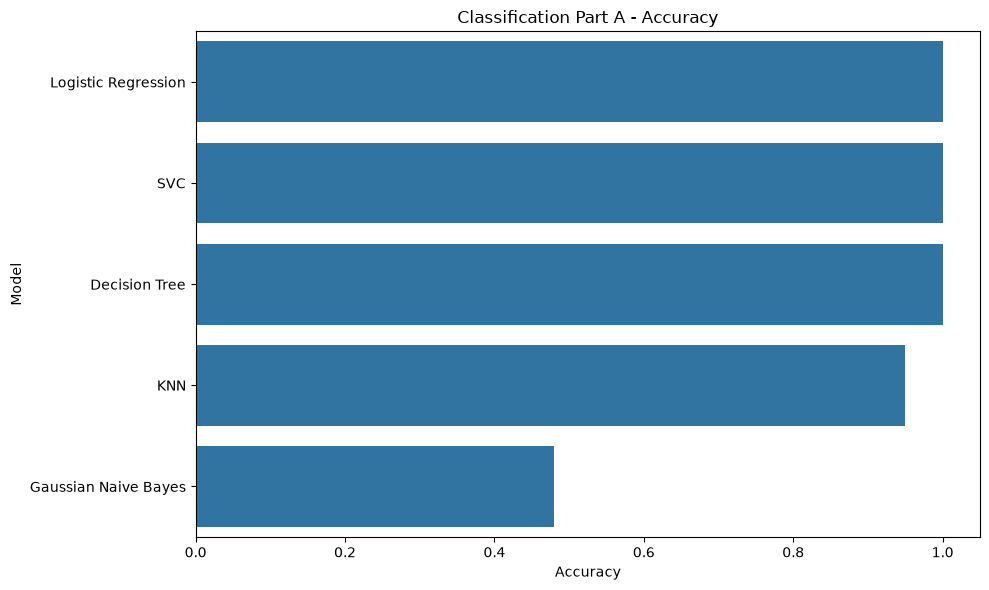

In [18]:
#Accuracy Graph
plt.figure(figsize=(10, 6))

sns.barplot(
    data=classification_results,
    x="Accuracy",
    y="Model"
)

plt.title(
    "Classification Part A - Accuracy"
)

plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

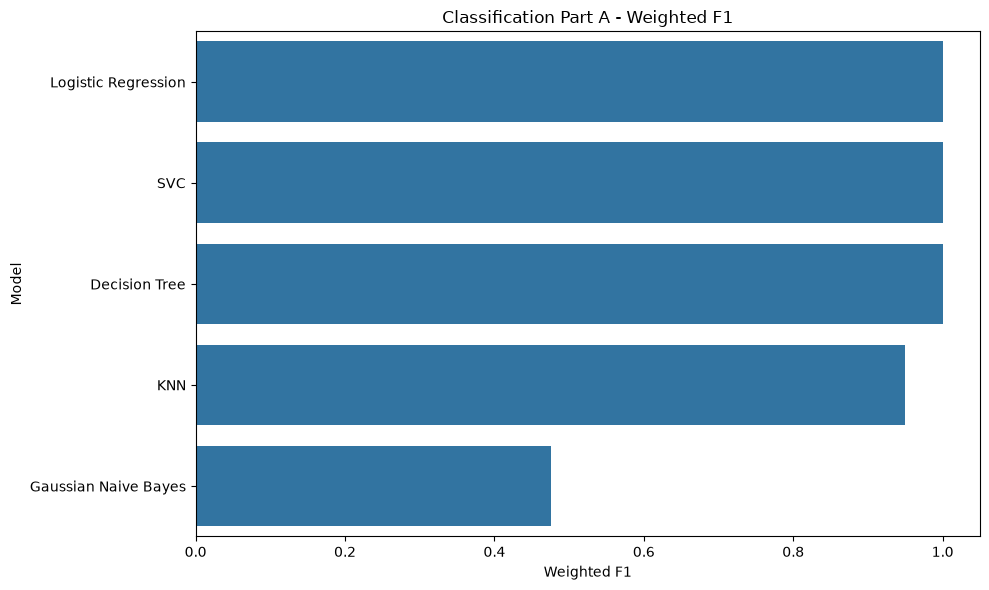

In [19]:
#F1 Graph
plt.figure(figsize=(10, 6))

sns.barplot(
    data=classification_results,
    x="F1 Weighted",
    y="Model"
)

plt.title(
    "Classification Part A - Weighted F1"
)

plt.xlabel("Weighted F1")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

In [20]:
roc_auc_results = []

for name, model in trained_models.items():

    y_proba = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(
        y_test,
        y_proba
    )

    roc_auc_results.append({
        "Model": name,
        "ROC-AUC": auc
    })

roc_auc_df = pd.DataFrame(roc_auc_results)

display(roc_auc_df)

,Model,ROC-AUC
0,Logistic Regression,1.0000
1,KNN,0.9861
2,Gaussian Naive Bayes,0.4869
3,Decision Tree,1.0000
4,SVC,1.0000


In [21]:
final_results = pd.DataFrame(results)

final_results = final_results.merge(
    roc_auc_df,
    on="Model"
)

display(final_results)

,Model,Accuracy,Precision,Recall,F1 Weighted,ROC-AUC
0,Logistic Regression,1.00,1.00000,1.00,1.000000,1.0000
1,KNN,0.95,0.95000,0.95,0.950000,0.9861
2,Gaussian Naive Bayes,0.48,0.47933,0.48,0.475754,0.4869
3,Decision Tree,1.00,1.00000,1.00,1.000000,1.0000
4,SVC,1.00,1.00000,1.00,1.000000,1.0000


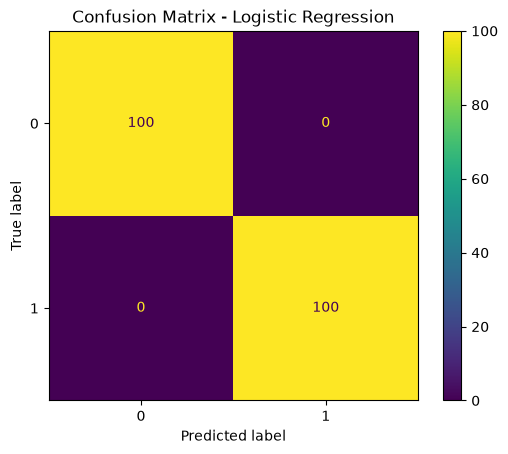

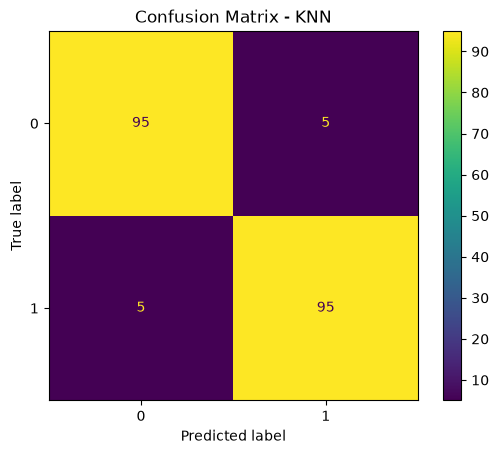

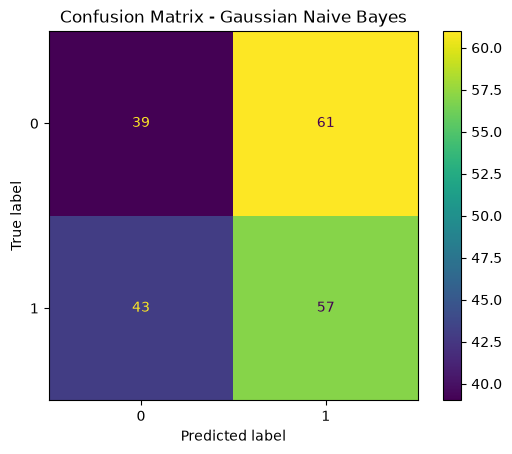

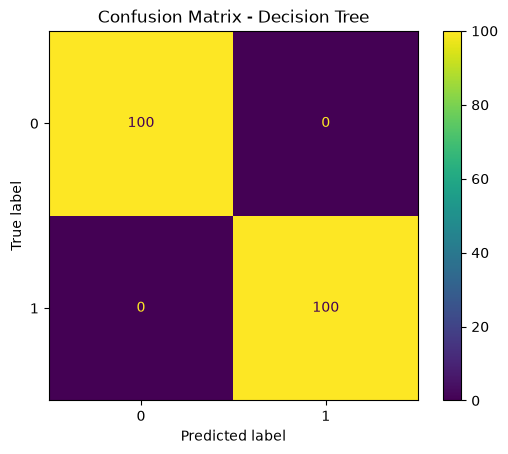

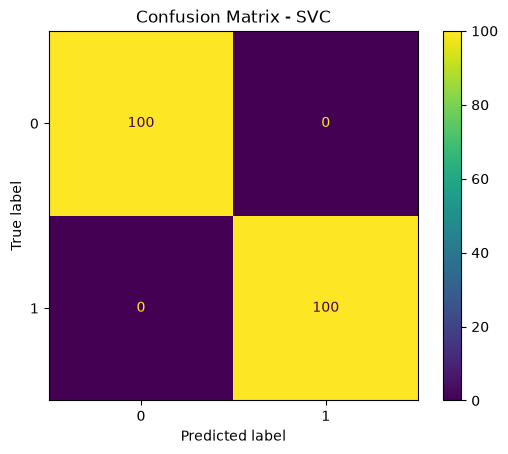

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=sorted(y.unique())
    )

    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [23]:
## Classification Part A Observations

#The five Classification Part A models were trained and evaluated using
#the same training and testing data.

#The models were evaluated using Accuracy, Precision, Recall,
#Weighted F1-score and ROC-AUC.

#Logistic Regression, Decision Tree and SVC achieved perfect
#classification performance on the test set, while KNN showed a small
#number of misclassifications.

#Gaussian Naive Bayes showed considerably lower performance compared
#with the other models.

#The confusion matrices were used to examine the classification errors
#between the two target classes.

#Since the target variable `touch_screen` contains two classes,
#ROC-AUC was calculated using the binary classification approach.